In [ ]:
 from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 27.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


In [ ]:
df = pd.read_csv(path+'/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop('PassengerId',axis=1,inplace=True)
df.drop('Name',axis=1,inplace=True)
df.drop('Ticket',axis=1,inplace=True)
df.drop('Cabin',axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)

<ipython-input-6-e0c0624688bb>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [ ]:
df.dropna(subset=['Embarked'],inplace=True)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


<BarContainer object of 2 artists>

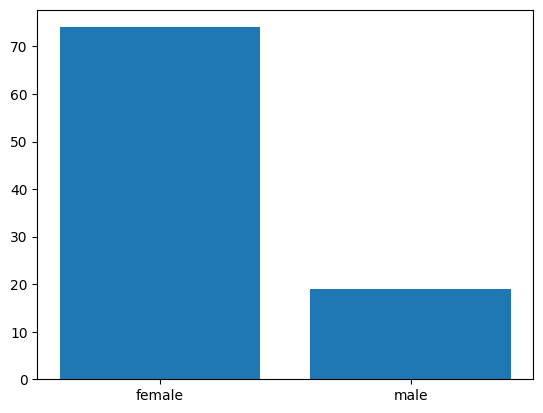

In [ ]:
sur_rate=df.groupby(['Sex'])['Survived'].mean() *100
plt.bar(['female','male'],sur_rate.values)

<BarContainer object of 3 artists>

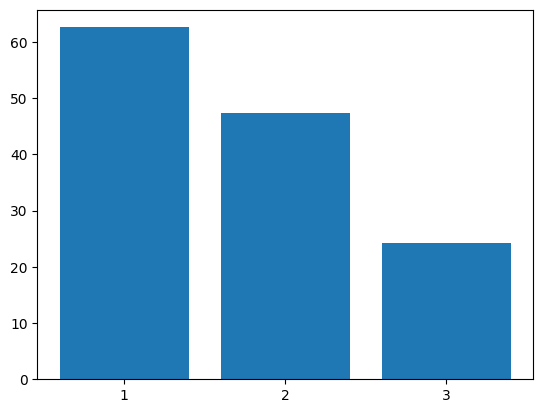

In [ ]:
sur_rate=df.groupby(['Pclass'])['Survived'].mean() *100
plt.bar(['1','2','3'],sur_rate.values)

<BarContainer object of 7 artists>

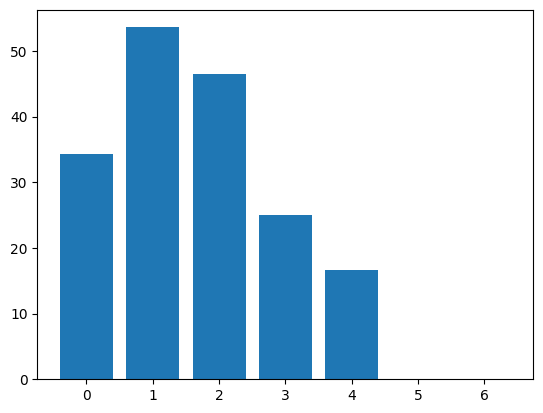

In [ ]:
sur_rate=df.groupby(['SibSp'])['Survived'].mean() *100
plt.bar(['0','1','2','3','4','5','6'],sur_rate.values)

<BarContainer object of 7 artists>

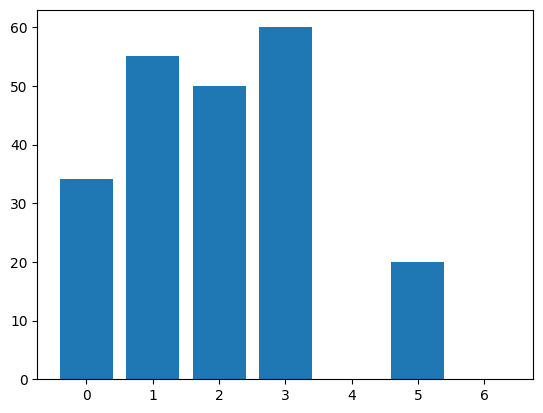

In [ ]:
sur_rate=df.groupby(['Parch'])['Survived'].mean() *100
plt.bar(['0','1','2','3','4','5','6'],sur_rate.values)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
df = df[df['Fare'] != 0]

In [ ]:
zero_fare_count = len(df[df['Fare'] == 0])
print(zero_fare_count)

0


In [ ]:
x=df.drop('Survived',axis=1)
y=df['Survived'].copy()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_num=X_train.select_dtypes(include=np.number)
x_cat=X_train.select_dtypes(include='object')

In [ ]:
from sklearn.preprocessing import FunctionTransformer
log_transformer=FunctionTransformer(np.log,inverse_func=np.exp)
log_pop=log_transformer.fit_transform(X_train[['Fare']])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline,make_pipeline
x_num_pipeline=Pipeline([('scaler',StandardScaler())])
x_num=pd.DataFrame(x_num_pipeline.fit_transform(x_num),columns=x_num.columns)
x_num

,Pclass,Age,SibSp,Parch,Fare
0,0.813446,-0.557671,-0.482784,-0.478390,-0.492820
1,0.813446,-0.710364,-0.482784,-0.478390,-0.465555
2,-1.600986,1.045602,-0.482784,0.760108,3.378595
3,-1.600986,0.129446,-0.482784,1.998606,2.497180
4,-1.600986,0.663870,-0.482784,0.760108,2.280876
...,...,...,...,...,...
694,0.813446,-0.099593,-0.482784,-0.478390,-0.482388
695,0.813446,-0.099593,-0.482784,-0.478390,-0.482862
696,0.813446,-0.786710,-0.482784,-0.478390,-0.480097
697,0.813446,-0.328632,0.414732,-0.478390,-0.482388


In [ ]:
from sklearn.preprocessing import OneHotEncoder
x_cat_pipeline=Pipeline([
    ('onehot',OneHotEncoder())
])
x_cat=pd.DataFrame(x_cat_pipeline.fit_transform(x_cat).toarray(),columns=x_cat_pipeline.get_feature_names_out())
x_cat

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
694,0.0,1.0,0.0,0.0,1.0
695,1.0,0.0,0.0,1.0,0.0
696,0.0,1.0,0.0,0.0,1.0
697,0.0,1.0,0.0,0.0,1.0


In [ ]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
x_num_cols=X_train.select_dtypes(include=np.number).columns
x_cat_cols=X_train.select_dtypes(include='object').columns

In [ ]:
from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer([
    ('num',x_num_pipeline,x_num_cols),
   ('cat',x_cat_pipeline,x_cat_cols)
])
X_train_prepared=pd.DataFrame(transformer.fit_transform(X_train),columns=transformer.get_feature_names_out())
X_test_prepared=pd.DataFrame(transformer.transform(X_test),columns=transformer.get_feature_names_out())
X_test_prepared

,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
0,0.813446,-0.252286,-0.482784,-0.478390,-0.480254,0.0,1.0,0.0,0.0,1.0
1,-1.600986,0.511178,-0.482784,-0.478390,1.942708,1.0,0.0,1.0,0.0,0.0
2,0.813446,-0.099593,-0.482784,-0.478390,-0.483257,0.0,1.0,0.0,1.0,0.0
3,-1.600986,0.511178,0.414732,-0.478390,0.865696,0.0,1.0,0.0,0.0,1.0
4,0.813446,0.205792,-0.482784,-0.478390,-0.477172,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
170,-0.393770,0.053099,-0.482784,-0.478390,-0.383285,0.0,1.0,0.0,0.0,1.0
171,0.813446,-0.252286,0.414732,-0.478390,-0.480886,0.0,1.0,0.0,0.0,1.0
172,0.813446,-0.099593,-0.482784,-0.478390,-0.482151,1.0,0.0,0.0,1.0,0.0
173,0.813446,-1.931905,0.414732,0.760108,-0.418691,0.0,1.0,0.0,0.0,1.0


In [ ]:
from sklearn.linear_model import LogisticRegression
full_pipe=make_pipeline(transformer, LogisticRegression())
full_pipe.fit(X_train,y_train)
full_pipe.score(X_test,y_test)

0.7942857142857143

In [ ]:
from sklearn.tree import DecisionTreeClassifier
full_pipeline=make_pipeline(transformer,DecisionTreeClassifier())
full_pipeline.fit(X_train,y_train)
full_pipeline.score(X_test,y_test)

0.7771428571428571

In [ ]:
from sklearn.ensemble import RandomForestClassifier
full_pipeline=make_pipeline(transformer,RandomForestClassifier())
full_pipeline.fit(X_train,y_train)
full_pipeline.score(X_test,y_test)

0.8057142857142857

In [ ]:
full_pipeline.predict(X_test.iloc[:10])

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0])

In [ ]:
y_test.iloc[:10]

,Survived
810,0
325,1
388,0
741,0
429,1
333,0
865,1
137,0
682,0
791,0


In [ ]:
from sklearn.metrics import mean_absolute_error
preds=full_pipeline.predict(X_test)
mean_absolute_error(y_test,preds)

0.2

In [ ]:
df.count()

,0
Survived,874
Pclass,874
Sex,874
Age,874
SibSp,874
Parch,874
Fare,874
Embarked,874


In [ ]:
# prompt: make a grid search on this data

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# Assuming X_train, X_test, y_train, y_test are defined from the previous code
x_num_cols = X_train.select_dtypes(include=np.number).columns
x_cat_cols = X_train.select_dtypes(include='object').columns

# Create transformers
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]) # Handle unknown categories in test set

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, x_num_cols),
        ('cat', categorical_transformer, x_cat_cols)
    ])

# Create pipeline with RandomForestClassifier
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier())])


# Define parameter grid
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test accuracy:", test_accuracy)

KeyboardInterrupt: 